# Visual Evaluation of a trained ArtFire Model


### Display a gif of the horizon frames

On the left x_t, in the middle the true y_seq, and, on the right the frames predicted frames

In [15]:
from ArtFire.DL.Models.ArtFire import Artfire
from ArtFire.DL.Models.CAE import CAE, ConvDecoder, ConvEncoder
from ArtFire.DL.Models.Forecast import ARTransformerForecaster
from ArtFire.utils.config import load_data_config, load_model_config, load_train_config
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from torch.utils.data import DataLoader
from ArtFire.Data.SimulatedDataset import SimulatedDataset

split=(0.6,0.2,0.2)
train_dataset = SimulatedDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="train",
    horizon=30,
    normalize=True
)
test_dataset = SimulatedDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="test",
    horizon=30,
    stats=train_dataset.get_stats(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
)



data_config = load_data_config()
model_config = load_model_config()
train_config = load_train_config()


CAEenc = ConvEncoder(
    model_config["CAE"]["spatial_conv_config"],
    model_config["CAE"]["temporal_conv_config"],
)
CAEdec = ConvDecoder(
    model_config["CAE"]["spatial_tconv_config"],
    model_config["CAE"]["temporal_tconv_config"],
    model_config["CAE"]["no_flatten_dim"],
)

CAEmodel = CAE(CAEenc, CAEdec).to(train_config["CAE"]["device"])
state_dict = torch.load("best_cae.pt", weights_only=True)
CAEmodel.load_state_dict(state_dict)

model_forecast = ARTransformerForecaster(
    n_tokens=model_config["Transformer"]["n_tokens"],
    token_dim=model_config["Transformer"]["token_dim"],
    d_model=model_config["Transformer"]["d_model"],
    n_heads=model_config["Transformer"]["n_heads"],
    n_layers=model_config["Transformer"]["n_layers"],
    mlp_config=model_config["Transformer"]["mlp_config"],
    dropout=model_config["Transformer"]["dropout"],
    use_residual=model_config["Transformer"]["use_residual"],
).to(train_config["Transformer"]["device"])
state_dict = torch.load("best_transformer.pt", weights_only=True)
model_forecast.load_state_dict(state_dict)
model = Artfire(cae=CAEmodel, forecast=model_forecast)

#state_dict = torch.load("best_artfire.pt", weights_only=True)
#model.load_state_dict(state_dict)
model=model.to("cpu")


batch = next(iter(test_loader))

# one sample from batch
x_t = batch["x_t"][0].cpu()       # [C, H, W]
y_seq = batch["x_seq"][0].cpu()   # [T, C, H, W]

with torch.no_grad():
    y_pred = model(batch["x_t"], horizon=30).cpu()[0]   # expected [T, C, H, W] for first sample

channel = 2
T = y_seq.shape[0]

# MSE over time: one value per future frame
# averages over all channels and spatial dimensions
mse_t = ((y_seq - y_pred) ** 2).mean(dim=(1, 2, 3)).cpu()   # [T]

# shared color scale for image panels
vmin = min(
    x_t[channel].min().item(),
    y_seq[:, channel].min().item(),
    y_pred[:, channel].min().item(),
)
vmax = max(
    x_t[channel].max().item(),
    y_seq[:, channel].max().item(),
    y_pred[:, channel].max().item(),
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax_x, ax_gt, ax_pred, ax_mse = axes

time_axis = torch.arange(1, T + 1).cpu().numpy()
mse_np = mse_t.numpy()

def update(frame):
    ax_x.clear()
    ax_gt.clear()
    ax_pred.clear()
    ax_mse.clear()

    # x_t
    ax_x.imshow(
        x_t[channel],
        cmap="inferno",
        interpolation="nearest",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax_x.set_title("x_t")
    ax_x.axis("off")

    # ground truth sequence
    ax_gt.imshow(
        y_seq[frame, channel],
        cmap="inferno",
        interpolation="nearest",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax_gt.set_title(f"GT t+{frame+1}")
    ax_gt.axis("off")

    # predicted sequence
    ax_pred.imshow(
        y_pred[frame, channel],
        cmap="inferno",
        interpolation="nearest",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )
    ax_pred.set_title(f"Pred t+{frame+1}")
    ax_pred.axis("off")

    # mse curve over time
    ax_mse.plot(time_axis, mse_np)
    ax_mse.scatter(time_axis[frame], mse_np[frame], s=50)
    ax_mse.set_title("MSE vs time")
    ax_mse.set_xlabel("time step")
    ax_mse.set_ylabel("MSE")
    ax_mse.set_xlim(1, T)
    ax_mse.set_ylim(0, max(mse_np) * 1.1 if max(mse_np) > 0 else 1.0)
    ax_mse.grid(True, alpha=0.3)

fig.tight_layout()

ani = animation.FuncAnimation(
    fig,
    update,
    frames=T,
    interval=200,
)

plt.close()
HTML(ani.to_jshtml())

Custom Convolutional Block

In [5]:
from ArtFire.DL.Models.convolution import CNNblock

In [6]:
cnn_block=CNNblock(input_channels=x_t.shape[0], output_channels=64, hidden_channels=[32], dim=2, paddings=0, strides=2)

In [7]:
cnn_block

CNNblock(
  (backbone): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
  )
)

Apply the convolutional block to an input from the data loader

In [8]:

x=next(iter(test_loader))["x_t"]
print(x.shape)
x=cnn_block(x)
x.shape   # 8=B , 64=C , 63=H, 15=W

torch.Size([8, 13, 256, 64])


torch.Size([8, 64, 63, 15])

At this point, consider that the H dimension is the time, permute to have [B,H,C,W] convolutional block


In [9]:
B=8
C=64
H=63
W=15
x=x.permute((0,2,1,3))
x = x.unsqueeze(2)               # → [B, H, 1, C, W]
x = x.reshape(B*H, 1, C, W)
x.shape

torch.Size([504, 1, 64, 15])

now we have batches of 63 tokens, each of shape 64x15

apply a second convolution to vectorize each 2d-token


In [10]:
import torch.nn as nn
cnn_block_2=CNNblock(input_channels=1, output_channels=64, hidden_channels=[32], dim=2, paddings=0, strides=2)
model=nn.Sequential(
    cnn_block_2,
    nn.AdaptiveAvgPool2d(1)
    )
model

Sequential(
  (0): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (1): AdaptiveAvgPool2d(output_size=1)
)

In [11]:
x=model(x)
x.shape

torch.Size([504, 64, 1, 1])

In [12]:
x=x.reshape((B,H,-1))
x.shape

torch.Size([8, 63, 64])

Now we have 63 tokens, each of them is a vector of dim 64. Now we can apply a transformer

Overall model is the following


In [60]:
class ConvEncoder(nn.Module):
    def __init__(self, config_spatial_conv, config_temporal_conv):
        super().__init__()
        self.sp_conv=CNNblock(**config_spatial_conv)
        self.t_conv=CNNblock(**config_temporal_conv)
        #self.pool=nn.AdaptiveAvgPool2d(output_size=1)

    def forward(self,x):
        x=self.sp_conv(x)
        B,C,H,W= x.shape
        x=x.permute((0,2,1,3)) # -> B,H,C,W
        x = x.unsqueeze(2)  # -> B,H,1,C,W
        x = x.reshape(B*H, 1, C, W)  # -> B*H,1,C,W
        x=self.t_conv(x)
        x=x.view(B,H,*x.shape[1:])
        return x.flatten(start_dim=2)#.reshape((B,H,-1))


In [65]:
x_t=next(iter(test_loader))["x_t"]

spatial_conv_config={"input_channels":x_t.shape[1], "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0, "strides":2}
temporal_conv_config ={"input_channels":1, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0,
                       "strides":2}

CAEenc=ConvEncoder(spatial_conv_config, temporal_conv_config)

CAEenc


ConvEncoder(
  (sp_conv): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (t_conv): CNNblock(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
)

In [66]:
y=CAEenc(x_t)
y.shape

torch.Size([8, 63, 2880])

Now we have 63 tokens, each of them is a vector of dim 64. Now we can apply a transformer

Apply transpose convolution to reconstruct input image

In [67]:
from ArtFire.DL.Models.convolution import TCNNblock
class ConvDecoder(nn.Module):
    def __init__(self, config_spatial_tconv, config_temporal_tconv, no_flatten_dim):
        super().__init__()
        self.sp_tconv=TCNNblock(**config_spatial_tconv)
        self.t_tconv=TCNNblock(**config_temporal_tconv)
        self.C2, self.H2 , self.W2=no_flatten_dim



    def forward(self,x):
        B, H = x.shape[:2]
        x=x.view(B* H, self.C2, self.H2, self.W2)
        x=self.t_tconv(x)
        x=x.view(B, H,*x.shape[1:])
        x=x.squeeze(dim=2)
        x=x.permute(0,2,1,3)
        return self.sp_tconv(x)




In [41]:


spatial_tconv_config={"input_channels":64, "output_channels":13, "hidden_channels":[32], "dim":2, "paddings":0,
                      "output_paddings":[(0, 0), (1, 0)],"strides":2}
temporal_tconv_config ={"input_channels":64, "output_channels":1, "hidden_channels":[32], "dim":2, "paddings":0,"output_paddings":[(0, 0), (1, 0)], "strides":2}



CAEdec=ConvDecoder(spatial_tconv_config, temporal_tconv_config, no_flatten_dim=(64,15,3))
CAEdec




ConvDecoder(
  (sp_tconv): TCNNblock(
    (backbone): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): ConvTranspose2d(32, 13, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0), bias=False)
      (4): BatchNorm2d(13, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
    )
  )
  (t_tconv): TCNNblock(
    (backbone): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 0), bias=False)
      (4): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate=

In [1]:
from ArtFire.DL.Models.CAE import CAE, ConvEncoder, ConvDecoder
from ArtFire.Data.CAEDataset import CAEDataset
from ArtFire.DL.Optimization.optimizers import build_optimizer, build_parameter_groups
from pytorch_scheduler.scheduler.polynomial import PolynomialScheduler
from pytorch_scheduler.base.warmup import WarmupScheduler

In [2]:
from torch.utils.data import DataLoader

split = (0.7, 0.15, 0.15)

train_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="train",
    normalize=True,
)

val_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="val",
    normalize=True,
    stats=train_dataset.get_stats(),
)
test_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=split,
    mode="test",
    normalize=True,
    stats=train_dataset.get_stats(),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

batch = next(iter(train_loader))
print(batch["x"].shape)  # [B, 13, 256, 64]
print(batch["y"].shape)  # [B, 13, 256, 64]

torch.Size([8, 13, 256, 64])
torch.Size([8, 13, 256, 64])


In [3]:
spatial_conv_config={"input_channels":13, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0, "strides":2}
temporal_conv_config ={"input_channels":1, "output_channels":64, "hidden_channels":[32], "dim":2, "paddings":0,
                       "strides":2}

CAEenc=ConvEncoder(spatial_conv_config, temporal_conv_config)

spatial_tconv_config={"input_channels":64, "output_channels":13, "hidden_channels":[32], "dim":2, "paddings":0,
                      "output_paddings":[(0, 0), (1, 1)],"strides":2}
temporal_tconv_config ={"input_channels":64, "output_channels":1, "hidden_channels":[32], "dim":2, "paddings":0,"output_paddings":[(0, 0), (1, 0)], "strides":2}



CAEdec=ConvDecoder(spatial_tconv_config, temporal_tconv_config, no_flatten_dim=(64,15,3))




CAEmodel=CAE(CAEenc,CAEdec)
CAEmodel

CAE(
  (ConvEncoder): ConvEncoder(
    (sp_conv): CNNblock(
      (backbone): Sequential(
        (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
      )
    )
    (t_conv): CNNblock(
      (backbone): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): GELU(approximate='none')
      )
    )
  )
 

In [4]:


import torch
import torch.nn as nn
from tqdm import tqdm



def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader):
        x = batch["x"].to(device)   # CAEDataset
        y = batch["y"].to(device)

        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)

        y_hat = model(x)
        loss = criterion(y_hat, y)

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CAEmodel.to(device)

parameters_groups=build_parameter_groups(CAEmodel, 0.0001, 0.00005)
optimizer=build_optimizer(params=parameters_groups[1],
   config= {
    "name":"adamw",
    "use_lookahead": True}
)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#scheduler= PolynomialScheduler(optimizer=optimizer, total_steps=20, power=1, min_lr=1e-7)
#warmup_scheduler=WarmupScheduler(optimizer, scheduler, warmup_steps=5, warmup_type="linear")


criterion = nn.MSELoss()
num_epochs = 3 #20

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1:03d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_cae.pt")

100%|██████████| 175/175 [00:12<00:00, 14.02it/s]


Epoch 001 | train loss: 1.265184 | val loss: 0.355585


100%|██████████| 175/175 [00:12<00:00, 14.13it/s]


Epoch 002 | train loss: 0.174009 | val loss: 0.096250


100%|██████████| 175/175 [00:12<00:00, 13.99it/s]


Epoch 003 | train loss: 0.078340 | val loss: 0.066598


In [6]:
model.load_state_dict(torch.load("best_cae.pt", map_location=device))
test_loss = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.6f}")

C:\Users\carlo\AppData\Local\Temp\ipykernel_3040\2951192782.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_cae.pt", map_location=

Test loss: 0.066429


# Now train the forecaster

In [7]:
from ArtFire.Data.ForecastDataset import ForecastDataset


In [8]:
full_cae_dataset = CAEDataset(
    npy_path="D_t2001_f13_z256_x64.npy",
    split=(1.0, 0.0, 0.0),   # IMPORTANT → full dataset
    mode="train",
    normalize=True,
)

full_cae_dataloader = DataLoader(
    train_dataset,
    batch_size=12,
    shuffle=False, # do not shuffle for time series
    num_workers=0,
)

In [9]:
split = (0.6, 0.2, 0.2)

train_forecast = ForecastDataset(
    cae_dataset=full_cae_dataloader,
    encoder=model.ConvEncoder,
    split=split,
    mode="train",
    horizon=10,
    normalize=True,
)

val_forecast = ForecastDataset(
    cae_dataset=full_cae_dataloader,
    encoder=model.ConvEncoder,
    split=split,
    mode="val",
    horizon=10,
    normalize=True,
    stats=train_forecast.get_stats(),
)

test_forecast = ForecastDataset(
    cae_dataset=full_cae_dataloader,
    encoder=model.ConvEncoder,
    split=split,
    mode="test",
    horizon=10,
    normalize=True,
    stats=train_forecast.get_stats(),
)

train_dataloader=DataLoader(
    train_forecast,
    batch_size=12,
    shuffle=False, # do not shuffle for time series
    num_workers=0,
)

val_dataloader=DataLoader(
    val_forecast,
    batch_size=12,
    shuffle=False, # do not shuffle for time series
    num_workers=0,
)

test_dataloader=DataLoader(
    test_forecast,
    batch_size=12,
    shuffle=False, # do not shuffle for time series
    num_workers=0,
)

Encoding full dataset: 100%|██████████| 117/117 [00:03<00:00, 36.68it/s]


In [10]:
d_t=next(iter(train_forecast))

In [11]:
d_t["z_t"].shape

torch.Size([63, 2880])

In [12]:
import torch
import torch.nn.functional as F

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        z_t = batch["z_t"].to(device)       # [B, 63, 2880]
        z_seq = batch["z_seq"].to(device)   # [B, H, 63, 2880]

        horizon = z_seq.shape[1]

        optimizer.zero_grad()
        pred_seq = model(z_t, horizon=horizon)   # [B, H, 63, 2880]

        loss = F.mse_loss(pred_seq, z_seq)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
from ArtFire.DL.Models.Forecast import ARTransformerForecaster
model_forecast = ARTransformerForecaster(
    n_tokens=63,
    token_dim=2880,
    d_model=512,
    n_heads=8,
    n_layers=4,
    mlp_config={"hidden_layers":[256], "dropout_p": 0.0, "normalization":None,
                 "activation":"leaky_relu", "seed":42, "initialization": "default"},
    dropout=0.1,
    use_residual=True,
)

In [21]:
from typing import Dict, Any
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device | str,
    loss_fn: nn.Module | None = None,
    grad_clip: float | None = None,
) -> Dict[str, float]:
    model.train()
    loss_fn = loss_fn or nn.MSELoss()

    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        z_t = batch["z_t"].to(device)       # [B, N, D]
        z_seq = batch["z_seq"].to(device)   # [B, H, N, D]

        horizon = z_seq.shape[1]

        optimizer.zero_grad()

        pred_seq = model(z_t, horizon=horizon)   # [B, H, N, D]
        loss = loss_fn(pred_seq, z_seq)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    return {"loss": avg_loss}

In [27]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device | str,
    loss_fn: nn.Module | None = None,
) -> Dict[str, float]:
    model.eval()
    loss_fn = loss_fn or nn.MSELoss()

    total_loss = 0.0
    n_batches = 0

    for batch in tqdm(loader):
        z_t = batch["z_t"].to(device)       # [B, N, D]
        z_seq = batch["z_seq"].to(device)   # [B, H, N, D]

        horizon = z_seq.shape[1]

        pred_seq = model(z_t, horizon=horizon)
        loss = loss_fn(pred_seq, z_seq)

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    return {"loss": avg_loss}

In [28]:
import copy


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    n_epochs: int,
    device: torch.device | str,
    loss_fn: nn.Module | None = None,
    grad_clip: float | None = None,
    scheduler: Any | None = None,
    verbose: bool = True,
) -> Dict[str, Any]:
    loss_fn = loss_fn or nn.MSELoss()

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_val_loss = float("inf")
    best_state_dict = copy.deepcopy(model.state_dict())
    best_epoch = -1

    model.to(device)

    for epoch in tqdm(range(1, n_epochs + 1)):
        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            loss_fn=loss_fn,
            grad_clip=grad_clip,
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            device=device,
            loss_fn=loss_fn,
        )

        train_loss = train_metrics["loss"]
        val_loss = val_metrics["loss"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if scheduler is not None:
            # for ReduceLROnPlateau
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if verbose:
            print(
                f"Epoch {epoch:03d} | "
                f"train loss: {train_loss:.6f} | "
                f"val loss: {val_loss:.6f}"
            )

    model.load_state_dict(best_state_dict)

    return {
        "history": history,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }

In [29]:
@torch.no_grad()
def test_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device | str,
    loss_fn: nn.Module | None = None,
) -> Dict[str, float]:
    test_metrics = evaluate(
        model=model,
        loader=test_loader,
        device=device,
        loss_fn=loss_fn,
    )
    print(f"Test loss: {test_metrics['loss']:.6f}")
    return test_metrics

In [30]:
next(iter(train_dataloader))["z_t"].shape

torch.Size([12, 63, 2880])

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_forecast = model_forecast.to(device)

optimizer = torch.optim.AdamW(model_forecast.parameters(), lr=1e-4, weight_decay=1e-4)

results = fit(
    model=model_forecast,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    n_epochs=50,
    device=device,
    loss_fn=nn.MSELoss(),
    grad_clip=1.0,
)

test_metrics = test_model(
    model=model_forecast,
    test_loader=test_dataloader,
    device=device,
    loss_fn=nn.MSELoss(),
)

  2%|▏         | 1/50 [01:21<1:06:55, 81.95s/it]

Epoch 001 | train loss: 0.156423 | val loss: 0.127168



  4%|▍         | 2/50 [02:44<1:05:57, 82.45s/it]

Epoch 002 | train loss: 0.104802 | val loss: 0.121458



  6%|▌         | 3/50 [04:06<1:04:20, 82.14s/it]

...

Epoch 049 | train loss: 0.040025 | val loss: 0.057423



100%|██████████| 50/50 [1:09:44<00:00, 83.68s/it]


Epoch 050 | train loss: 0.048643 | val loss: 0.066237


100%|██████████| 23/23 [00:08<00:00,  2.75it/s]

Test loss: 0.047198


In [1]:
from ArtFire.DL.Models.MLP import CustomMLP
from ArtFire.DL.Optimization.optimizers import build_optimizer, build_parameter_groups
from pytorch_scheduler.scheduler.polynomial import PolynomialScheduler
from pytorch_scheduler.base.warmup import WarmupScheduler
import torch
import matplotlib.pyplot as plt


In [2]:
model=CustomMLP(input_dim=100, output_dim=10, hidden_layers=[64,32], dropout_p=0.1, normalization="Batch-Norm", activation="leaky_relu", initialization="default")


In [3]:
model

CustomMLP(
  (backbone): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=10, bias=True)
  )
)

# Split Parameters into regularized ones and non-regularized ones
Do not regularize biases and normalization parameters

In [21]:
parameters_groups=build_parameter_groups(model, 1, 0.000006)
parameters_groups[1]

[{'params': [Parameter containing:
   tensor([[ 0.0406,  0.0135,  0.0427,  ..., -0.0456,  0.0984,  0.0982],
           [ 0.0150,  0.0514,  0.0595,  ...,  0.0493, -0.0852, -0.0762],
           [ 0.0023, -0.0693, -0.0587,  ..., -0.0496, -0.0221,  0.0340],
           ...,
           [ 0.0489,  0.0666, -0.0228,  ...,  0.0922, -0.0513,  0.0712],
           [ 0.0852,  0.0429,  0.0404,  ..., -0.0943, -0.0220,  0.0262],
           [-0.0287,  0.0122,  0.0071,  ...,  0.0037, -0.0772,  0.0513]],
          requires_grad=True),
   Parameter containing:
   tensor([[-0.1040,  0.1186, -0.0686,  ..., -0.1153, -0.0525, -0.0269],
           [ 0.0660,  0.0259, -0.0714,  ...,  0.1084, -0.0285,  0.0629],
           [ 0.1228,  0.0547,  0.0092,  ..., -0.0786, -0.0394, -0.0286],
           ...,
           [-0.0661,  0.0143,  0.0751,  ...,  0.0992,  0.0835,  0.0861],
           [ 0.0650,  0.1210, -0.0797,  ...,  0.0060,  0.0483,  0.1246],
           [ 0.0173, -0.0298,  0.0500,  ..., -0.0677, -0.1086,  0.1187]],

# Set-up an AdamW optimizer with lookahead

In [22]:
optimizer=build_optimizer(params=parameters_groups[1],
   config= {
    "name":"adamw",
    "use_lookahead": True}
)

In [23]:
optimizer

Lookahead (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1
    maximize: False
    weight_decay: 6e-06

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1
    maximize: False
    weight_decay: 0.0
)

# Set-up a lr scheduler

In [29]:
scheduler= PolynomialScheduler(optimizer=optimizer, total_steps=10000, power=3, min_lr=1e-5)

In [33]:
warmup_scheduler=WarmupScheduler(optimizer, scheduler,min_lr=5e-5 ,max_lr=1e-2,warmup_steps=1000, warmup_type="linear")
warmup_scheduler

In [31]:
lrs=[]
for step in range(10000):
    lrs.append(optimizer.param_groups[0]["lr"])
    warmup_scheduler.step()

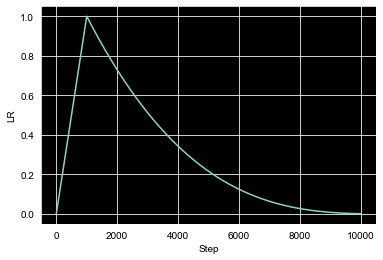

In [32]:
plt.plot(lrs)

plt.xlabel("Step", color="black")
plt.ylabel("LR", color="black")

plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')

plt.grid(True)

plt.show()

In [28]:
lrs

[5e-05,
 0.00104995,
 0.0020499000000000003,
 0.0030498500000000002,
 0.0040498,
 0.0050497499999999996,
 0.0060497,
 0.00704965,
 0.0080496,
 0.009049549999999998,
 0.0100495,
 0.011049449999999999,
 0.0120494,
 0.01304935,
 0.0140493,
 0.015049249999999998,
 0.016049200000000003,
 0.017049150000000002,
 0.0180491,
 0.01904905,
 0.020049,
 0.021048950000000004,
 0.0220489,
 0.023048850000000003,
 0.024048800000000002,
 0.02504875,
 0.0260487,
 0.02704865,
 0.028048600000000003,
 0.029048550000000003,
 0.0300485,
 0.031048450000000002,
 0.032048400000000005,
 0.033048350000000004,
 0.034048300000000004,
 0.03504825,
 0.036048199999999996,
 0.03704815,
 0.0380481,
 0.03904805,
 0.040048,
 0.04104795000000001,
 0.042047900000000006,
 0.04304785,
 0.0440478,
 0.04504775,
 0.046047700000000004,
 0.04704765,
 0.0480476,
 0.04904755,
 0.0500475,
 0.05104745,
 0.0520474,
 0.05304735,
 0.0540473,
 0.05504725,
 0.056047200000000005,
 0.057047150000000005,
 0.058047100000000004,
 0.05904705,
 0.